In [2]:
%pip install numpy matplotlib pillow

     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     -------------- ----------------------- 30.7/80.3 kB 435.7 kB/s eta 0:00:01
     ----------------------------- -------- 61.4/80.3 kB 544.7 kB/s eta 0:00:01
     -------------------------------------- 80.3/80.3 kB 636.6 kB/s eta 0:00:00
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/127.4 kB ? eta -:--:--
     ---------------------------- ---------- 92.2/127.4 kB 2.6 MB/s eta 0:00:01
     -------------------------------------- 127.4/127.4 kB 1.5 MB/s eta 0:00:00
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
    --------------------------------------- 0.2/12.6 MB 6.9 MB/s eta 0:00:02
   - -------------------------


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:

from PIL import Image

In [8]:

image_path = 'Manipulacion_matricial_eb35358c7e6c3605e697.png'

# Cargar imagen y convertir a una matriz numpy
img_pil = Image.open(image_path)
matriz_original = np.array(img_pil)

print("¡Imagen cargada exitosamente en una matriz!")

¡Imagen cargada exitosamente en una matriz!


In [9]:
print(f"Forma de la matriz: {matriz_original.shape}")
print(f"Tipo de dato: {matriz_original.dtype}")
print(f"Valor máximo de píxel: {matriz_original.max()}")
print(f"Valor mínimo de píxel: {matriz_original.min()}")

# Imprimir una pequeña parte de la matriz (esquina superior izquierda)
print("\nPíxeles superiores izquierdos 2x2 (RGB):")
print(matriz_original[0:2, 0:2])

Forma de la matriz: (1347, 2041, 3)
Tipo de dato: uint8
Valor máximo de píxel: 255
Valor mínimo de píxel: 0

Píxeles superiores izquierdos 2x2 (RGB):
[[[109  91  69]
  [ 86  67  51]]

 [[134 117  94]
  [121 104  85]]]


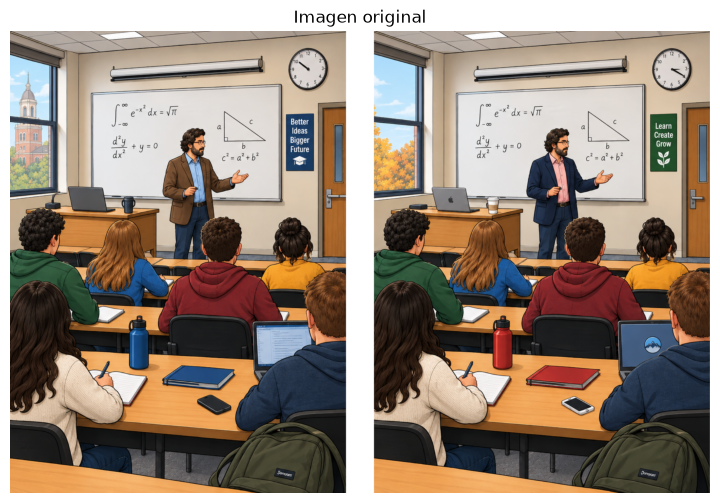

In [7]:
plt.figure(figsize=(10, 6))
plt.imshow(img_matrix)
plt.axis('off') # Oculta los ejes x e y
plt.title("Imagen original")
plt.show()

In [11]:
ancho_total = matriz_original.shape[1]
punto_medio = ancho_total // 2

matriz_izquierda = matriz_original[:, :punto_medio]
matriz_derecha = matriz_original[:, punto_medio:]


In [13]:
def recortar_bordes_blancos(matriz):
    # Consideramos "blanco" a cualquier píxel con valores RGB > 240
    # La máscara será True para píxeles que NO son blancos
    mascara_no_blanca = np.any(matriz < 240, axis=2)
    
    # Encontrar qué filas y columnas tienen al menos un píxel no blanco
    filas_con_contenido = np.any(mascara_no_blanca, axis=1)
    columnas_con_contenido = np.any(mascara_no_blanca, axis=0)
    
    # Obtener los índices mínimos y máximos (bounding box)
    y_min, y_max = np.where(filas_con_contenido)[0][[0, -1]]
    x_min, x_max = np.where(columnas_con_contenido)[0][[0, -1]]
    
    # Recortar la matriz (el +1 en max es porque el slicing en Python excluye el límite superior)
    return matriz[y_min:y_max+1, x_min:x_max+1]

In [14]:
# 4. Aplicar el recorte a ambas mitades
matriz_izq_recortada = recortar_bordes_blancos(matriz_izquierda)
matriz_der_recortada = recortar_bordes_blancos(matriz_derecha)

# 5. Convertir de nuevo a imágenes PIL y guardar
img_izq_final = Image.fromarray(matriz_izq_recortada)
img_der_final = Image.fromarray(matriz_der_recortada)

In [17]:
img_izq_final.save('img_izq_diferencias.jpg')
img_der_final.save('img_derecha_diferencias.jpg')


In [16]:
print("¡Imágenes extraídas y bordes blancos eliminados con éxito!")
print(f"Tamaño imagen izquierda: {img_izq_final.size}")
print(f"Tamaño imagen derecha: {img_der_final.size}")

¡Imágenes extraídas y bordes blancos eliminados con éxito!
Tamaño imagen izquierda: (980, 1347)
Tamaño imagen derecha: (980, 1347)
